# 3. Single-Qubit Gates and Operations

This notebook explores the most common single-qubit gates. For each
gate we:
1. Build a tiny circuit starting from `|0>`
2. Draw the circuit
3. Look at the exact resulting state (Statevector probabilities)
4. Measure it many times on the Aer simulator and plot a histogram

## Step 1: Import libraries

In [1]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_distribution, plot_histogram
import numpy as np

simulator = AerSimulator()

## X gate (bit-flip / quantum NOT)

Flips `|0>` to `|1>`.

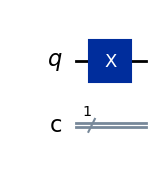

In [2]:
qc_x = QuantumCircuit(1, 1)
qc_x.x(0)
qc_x.draw("mpl")

X gate probabilities: {np.str_('1'): np.float64(1.0)}


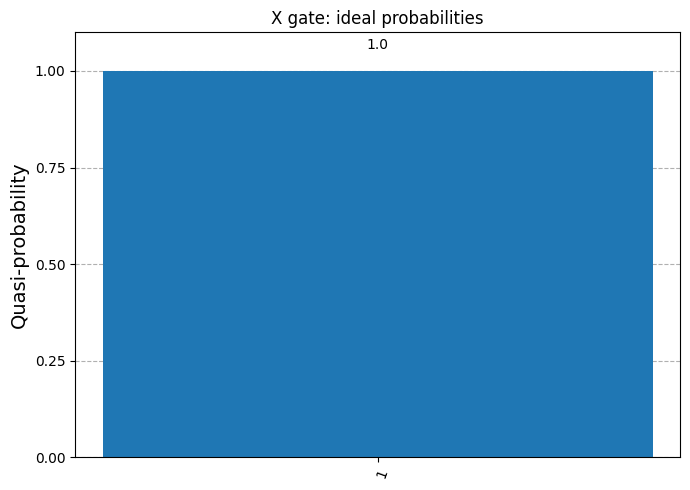

In [3]:
probs_x = Statevector(qc_x).probabilities_dict()
print("X gate probabilities:", probs_x)
plot_distribution(probs_x, title="X gate: ideal probabilities")

X gate measurement counts: {'1': 1024}


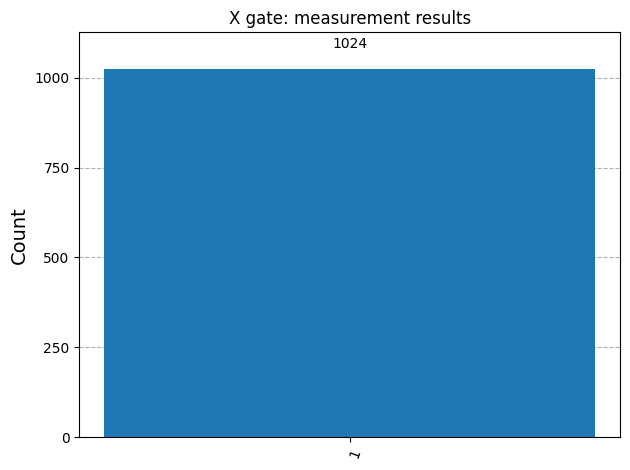

In [4]:
qc_x.measure(0, 0)
counts_x = simulator.run(transpile(qc_x, simulator), shots=1024).result().get_counts()
print("X gate measurement counts:", counts_x)
plot_histogram(counts_x, title="X gate: measurement results")

## Y gate

Similar to X, but also flips the phase.

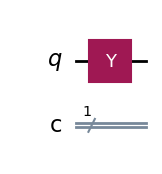

In [5]:
qc_y = QuantumCircuit(1, 1)
qc_y.y(0)
qc_y.draw("mpl")

Y gate probabilities: {np.str_('1'): np.float64(1.0)}


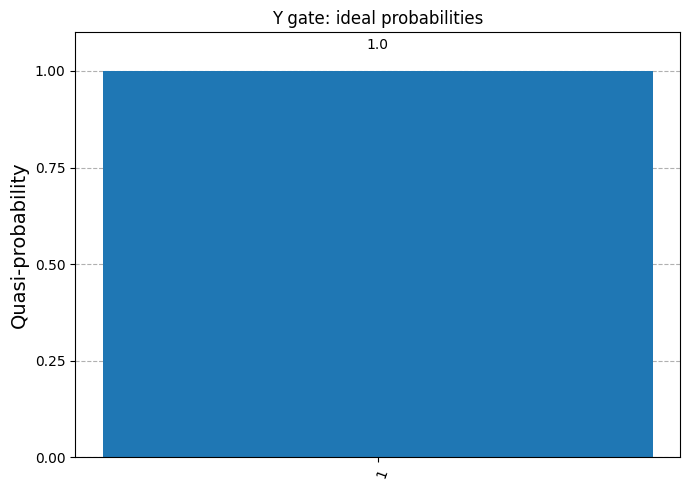

In [6]:
probs_y = Statevector(qc_y).probabilities_dict()
print("Y gate probabilities:", probs_y)
plot_distribution(probs_y, title="Y gate: ideal probabilities")

Y gate measurement counts: {'1': 1024}


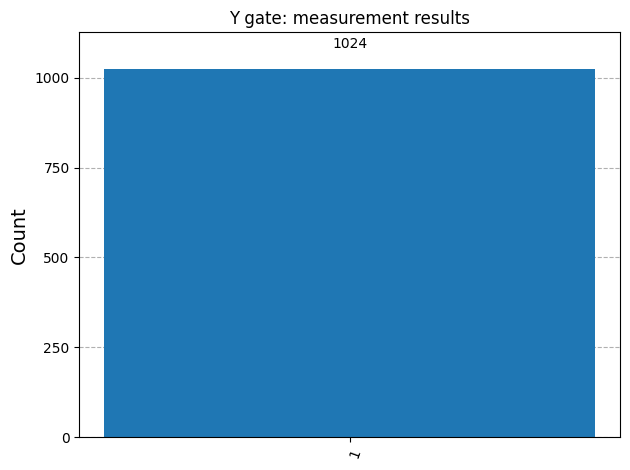

In [7]:
qc_y.measure(0, 0)
counts_y = simulator.run(transpile(qc_y, simulator), shots=1024).result().get_counts()
print("Y gate measurement counts:", counts_y)
plot_histogram(counts_y, title="Y gate: measurement results")

## Z gate (phase-flip)

Leaves `|0>` unchanged, but flips the sign of `|1>`. Since we start
at `|0>`, measurement still always gives `0` — the effect of Z is
only visible when the qubit is already in superposition (see the H
example below, and the phase gates section).

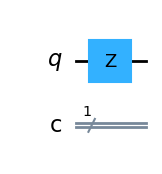

In [8]:
qc_z = QuantumCircuit(1, 1)
qc_z.z(0)
qc_z.draw("mpl")

Z gate probabilities: {np.str_('0'): np.float64(1.0)}


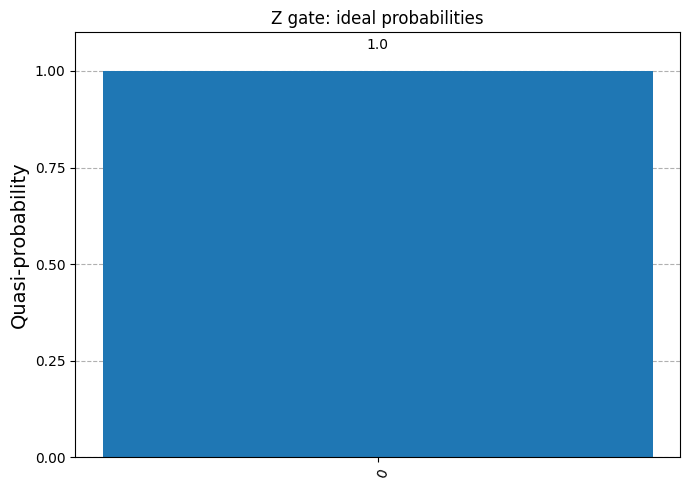

In [9]:
probs_z = Statevector(qc_z).probabilities_dict()
print("Z gate probabilities:", probs_z)
plot_distribution(probs_z, title="Z gate: ideal probabilities")

Z gate measurement counts: {'0': 1024}


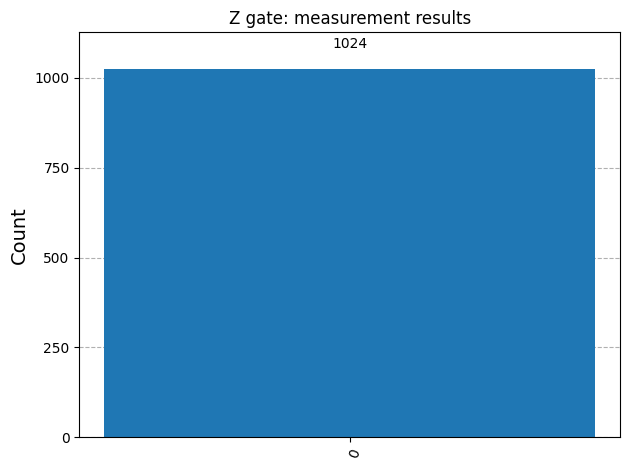

In [10]:
qc_z.measure(0, 0)
counts_z = simulator.run(transpile(qc_z, simulator), shots=1024).result().get_counts()
print("Z gate measurement counts:", counts_z)
plot_histogram(counts_z, title="Z gate: measurement results")

## H gate (Hadamard / superposition)

Creates an equal superposition of `|0>` and `|1>`.

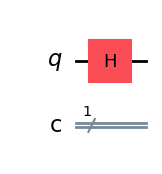

In [11]:
qc_h = QuantumCircuit(1, 1)
qc_h.h(0)
qc_h.draw("mpl")

H gate probabilities: {np.str_('0'): np.float64(0.4999999999999999), np.str_('1'): np.float64(0.4999999999999999)}


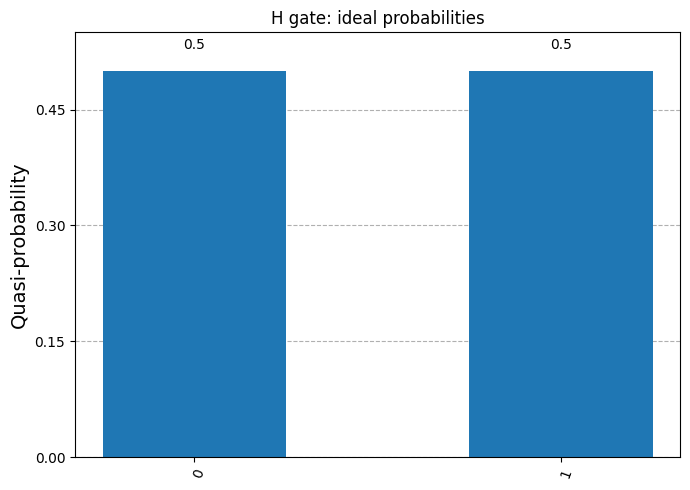

In [12]:
probs_h = Statevector(qc_h).probabilities_dict()
print("H gate probabilities:", probs_h)
plot_distribution(probs_h, title="H gate: ideal probabilities")

H gate measurement counts: {'1': 525, '0': 499}


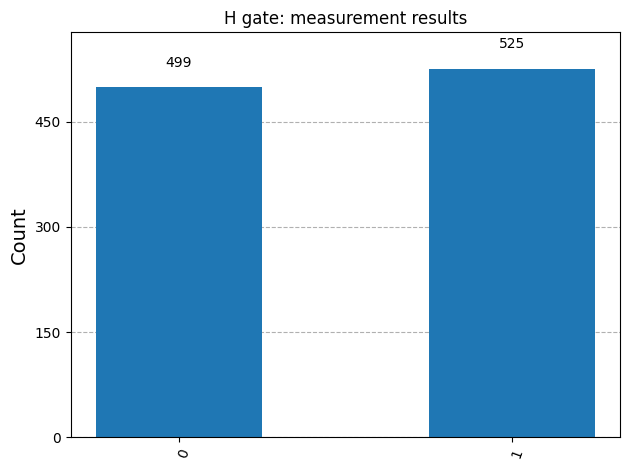

In [13]:
qc_h.measure(0, 0)
counts_h = simulator.run(transpile(qc_h, simulator), shots=1024).result().get_counts()
print("H gate measurement counts:", counts_h)
plot_histogram(counts_h, title="H gate: measurement results")

## S gate and T gate (phase gates)

S and T only add a phase — they don't change measurement
probabilities by themselves, so we apply them after an H gate to
make their effect visible in the statevector (the probabilities
still look 50/50, but the *phase* — not shown in a probability
chart — has changed, which matters when more gates follow).

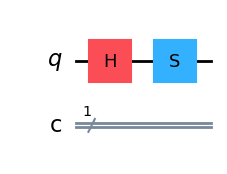

In [14]:
qc_s = QuantumCircuit(1, 1)
qc_s.h(0)
qc_s.s(0)
qc_s.draw("mpl")

H then S gate probabilities: {np.str_('0'): np.float64(0.4999999999999999), np.str_('1'): np.float64(0.4999999999999999)}


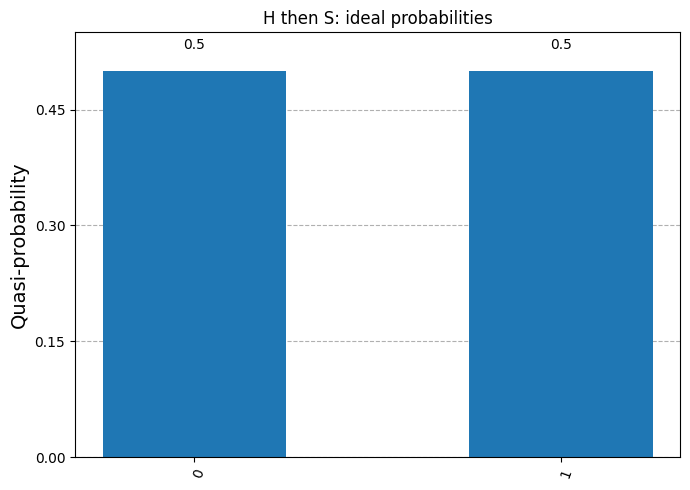

In [15]:
probs_s = Statevector(qc_s).probabilities_dict()
print("H then S gate probabilities:", probs_s)
plot_distribution(probs_s, title="H then S: ideal probabilities")

H then S measurement counts: {'1': 486, '0': 538}


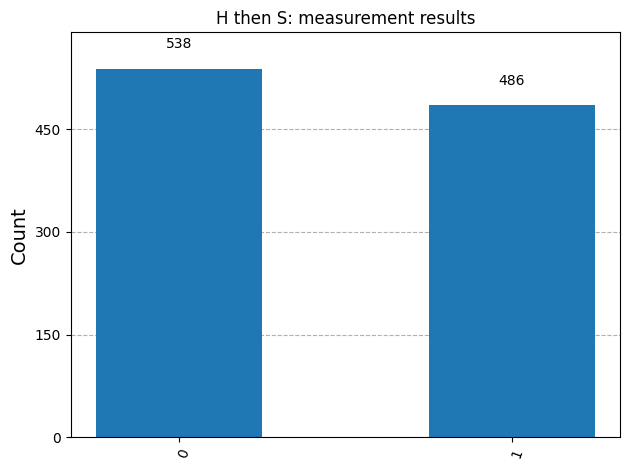

In [16]:
qc_s.measure(0, 0)
counts_s = simulator.run(transpile(qc_s, simulator), shots=1024).result().get_counts()
print("H then S measurement counts:", counts_s)
plot_histogram(counts_s, title="H then S: measurement results")

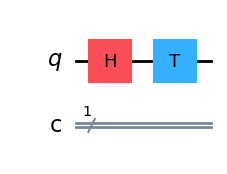

In [17]:
qc_t = QuantumCircuit(1, 1)
qc_t.h(0)
qc_t.t(0)
qc_t.draw("mpl")

H then T gate probabilities: {np.str_('0'): np.float64(0.4999999999999999), np.str_('1'): np.float64(0.4999999999999999)}


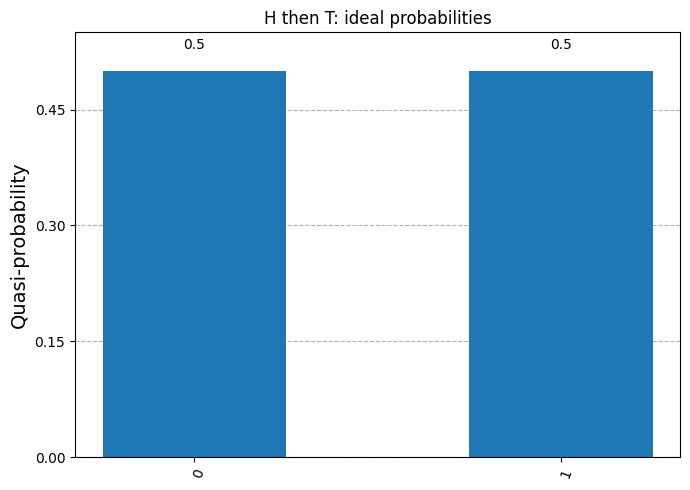

In [18]:
probs_t = Statevector(qc_t).probabilities_dict()
print("H then T gate probabilities:", probs_t)
plot_distribution(probs_t, title="H then T: ideal probabilities")

H then T measurement counts: {'1': 508, '0': 516}


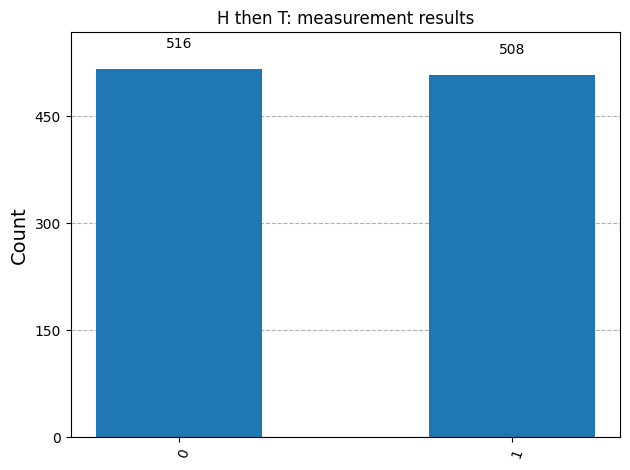

In [19]:
qc_t.measure(0, 0)
counts_t = simulator.run(transpile(qc_t, simulator), shots=1024).result().get_counts()
print("H then T measurement counts:", counts_t)
plot_histogram(counts_t, title="H then T: measurement results")

## Rotation gates: RX, RY, RZ

These rotate the qubit by a chosen angle. Here we rotate by 90
degrees (`pi/2` radians) around each axis.

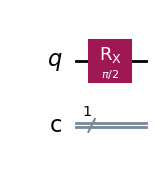

In [20]:
qc_rx = QuantumCircuit(1, 1)
qc_rx.rx(np.pi / 2, 0)
qc_rx.draw("mpl")

RX(pi/2) probabilities: {np.str_('0'): np.float64(0.5000000000000001), np.str_('1'): np.float64(0.4999999999999999)}


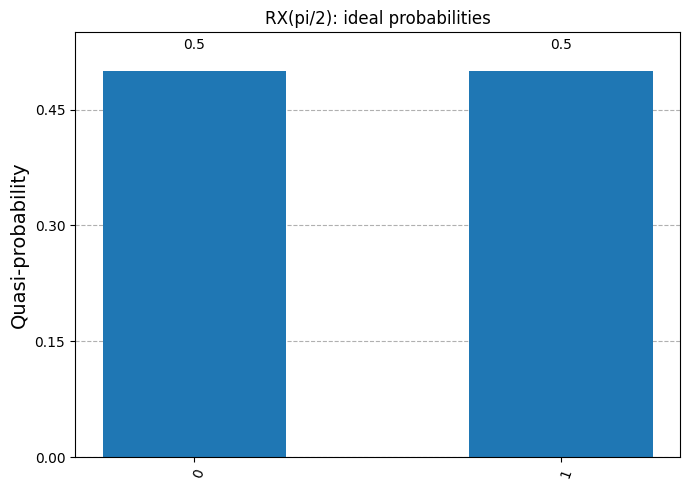

In [21]:
probs_rx = Statevector(qc_rx).probabilities_dict()
print("RX(pi/2) probabilities:", probs_rx)
plot_distribution(probs_rx, title="RX(pi/2): ideal probabilities")

RX(pi/2) measurement counts: {'1': 515, '0': 509}


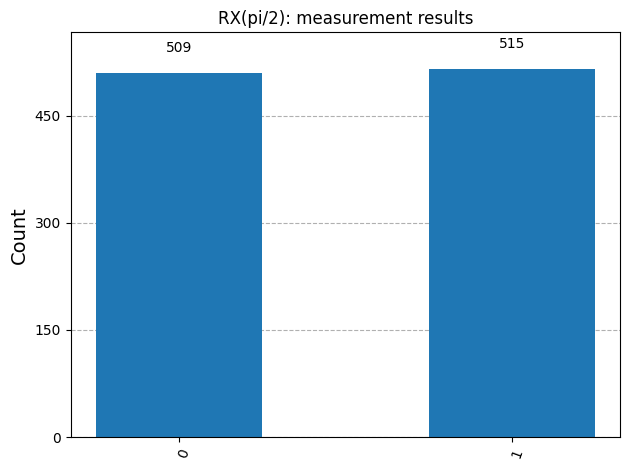

In [22]:
qc_rx.measure(0, 0)
counts_rx = simulator.run(transpile(qc_rx, simulator), shots=1024).result().get_counts()
print("RX(pi/2) measurement counts:", counts_rx)
plot_histogram(counts_rx, title="RX(pi/2): measurement results")

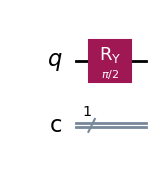

In [23]:
qc_ry = QuantumCircuit(1, 1)
qc_ry.ry(np.pi / 2, 0)
qc_ry.draw("mpl")

RY(pi/2) probabilities: {np.str_('0'): np.float64(0.5000000000000001), np.str_('1'): np.float64(0.4999999999999999)}


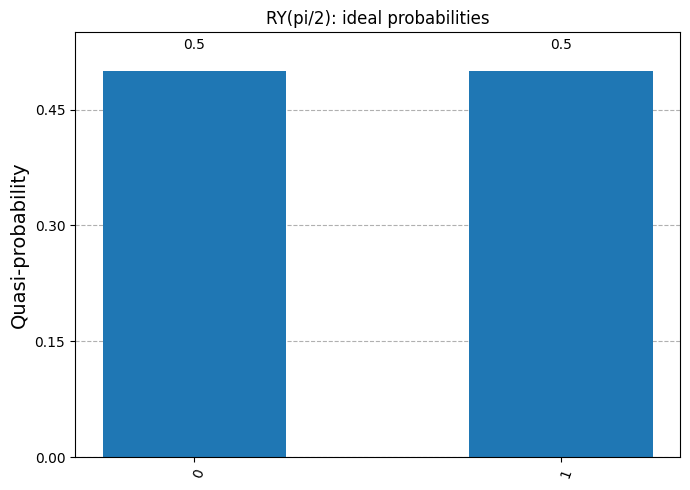

In [24]:
probs_ry = Statevector(qc_ry).probabilities_dict()
print("RY(pi/2) probabilities:", probs_ry)
plot_distribution(probs_ry, title="RY(pi/2): ideal probabilities")

RY(pi/2) measurement counts: {'1': 511, '0': 513}


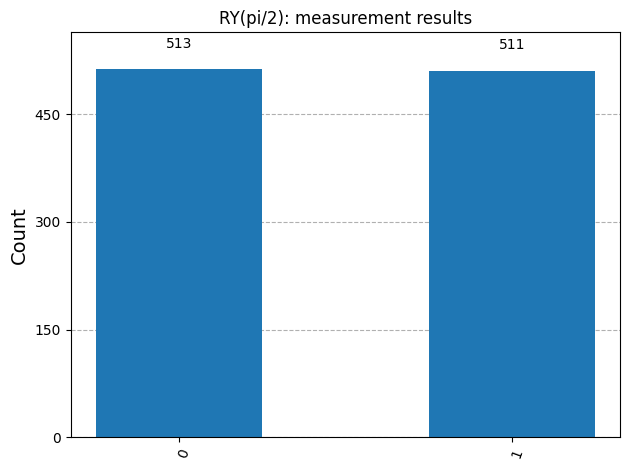

In [25]:
qc_ry.measure(0, 0)
counts_ry = simulator.run(transpile(qc_ry, simulator), shots=1024).result().get_counts()
print("RY(pi/2) measurement counts:", counts_ry)
plot_histogram(counts_ry, title="RY(pi/2): measurement results")

RZ only changes phase (like S and T), so we apply it after H to see
it in context, same as we did above.

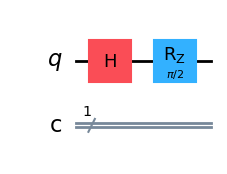

In [26]:
qc_rz = QuantumCircuit(1, 1)
qc_rz.h(0)
qc_rz.rz(np.pi / 2, 0)
qc_rz.draw("mpl")

H then RZ(pi/2) probabilities: {np.str_('0'): np.float64(0.4999999999999999), np.str_('1'): np.float64(0.4999999999999999)}


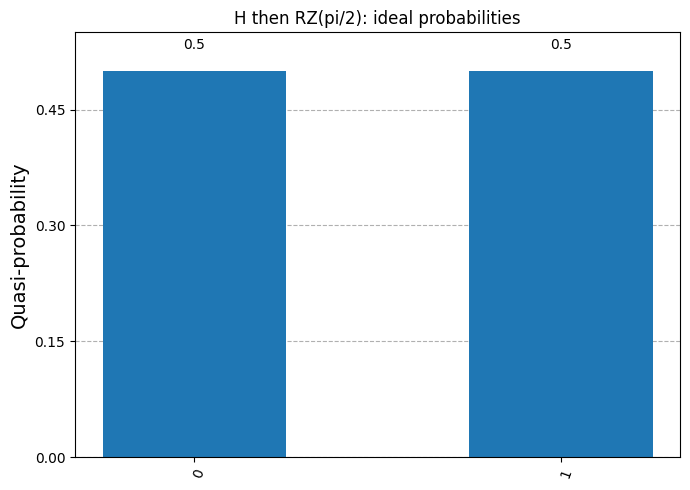

In [27]:
probs_rz = Statevector(qc_rz).probabilities_dict()
print("H then RZ(pi/2) probabilities:", probs_rz)
plot_distribution(probs_rz, title="H then RZ(pi/2): ideal probabilities")

H then RZ(pi/2) measurement counts: {'0': 511, '1': 513}


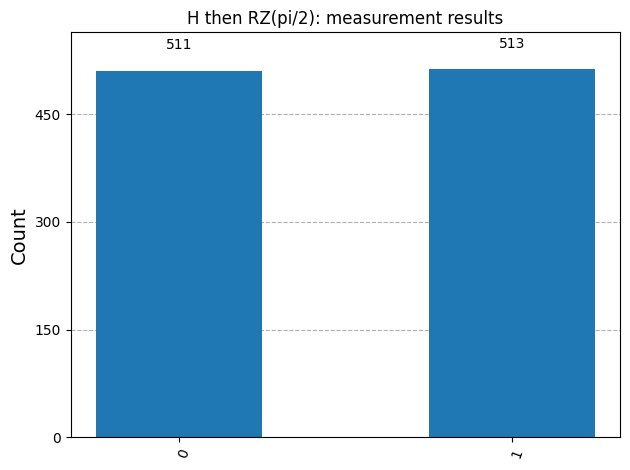

In [28]:
qc_rz.measure(0, 0)
counts_rz = simulator.run(transpile(qc_rz, simulator), shots=1024).result().get_counts()
print("H then RZ(pi/2) measurement counts:", counts_rz)
plot_histogram(counts_rz, title="H then RZ(pi/2): measurement results")

## Summary

- X, Y flip the qubit from `|0>` to `|1>` (deterministic: always `1`)
- Z leaves `|0>` unchanged (deterministic: always `0`)
- H creates a 50/50 superposition
- S, T, RZ only change phase — invisible in probabilities alone,
  but important once more gates are applied afterward
- RX, RY rotate the qubit and can create any mix of `0`/`1`
  probabilities depending on the angle